INST414 
MODULE 1
Ishika Reddy 

In [52]:
import requests
import pandas as pd
import networkx as nx

In [54]:
query = """
SELECT ?film ?filmLabel ?person ?personLabel WHERE {
  ?studio rdfs:label "A24"@en .
  ?film wdt:P272|wdt:P750 ?studio .
  ?film wdt:P161|wdt:P57 ?person .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
"""

response = requests.get(
    "https://query.wikidata.org/sparql",
    params={"query": query, "format": "json"},
    headers={"User-Agent": "INST414 student project"},
)
print(response.status_code)
results = response.json()["results"]["bindings"]
print(len(results))
print(results[0])
#USED CLAUDE ASSISTANCE

200
1994
{'film': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q1781285'}, 'person': {'type': 'uri', 'value': 'http://www.wikidata.org/entity/Q83287'}, 'filmLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Spring Breakers'}, 'personLabel': {'xml:lang': 'en', 'type': 'literal', 'value': 'Selena Gomez'}}


In [55]:
rows = []
for r in results:
    rows.append({
        "film_id": r["film"]["value"],
        "film": r["filmLabel"]["value"],
        "person_id": r["person"]["value"],
        "person": r["personLabel"]["value"],
    })

df = pd.DataFrame(rows).drop_duplicates()
print(len(df))
df.head(10)

1555


,film_id,film,person_id,person
0,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q83287,Selena Gomez
1,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q123174,Vanessa Hudgens
2,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q206032,Q206032
3,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q229349,Heather Morris
4,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q230609,Ashley Benson
5,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q306403,James Franco
6,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q352873,Jeff Jarrett
7,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q3787526,Rachel Korine
8,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q6514072,Lee Irby
9,http://www.wikidata.org/entity/Q1781285,Spring Breakers,http://www.wikidata.org/entity/Q21155081,Tom Franco


In [58]:
g = nx.Graph()

for film_id, film_rows in df.groupby("film_id"):

    people = film_rows[["person_id", "person"]].values.tolist()

    for person_id, person_name in people:
        g.add_node(person_id, name=person_name)

    #Every pair gets an edge
    i = 0
    for left_id, left_name in people:
        for right_id, right_name in people[i+1:]:
            if g.has_edge(left_id, right_id):
                g[left_id][right_id]["weight"] += 1
            else:
                g.add_edge(left_id, right_id, weight=1)
        i += 1

print("Nodes:", len(g.nodes))
print("Edges:", len(g.edges))

Nodes: 1302
Edges: 10675


In [60]:
c_degree = nx.degree_centrality(g)
c_eigen = nx.eigenvector_centrality(g, max_iter=1000)
c_between = nx.betweenness_centrality(g)

#All three measures in one table
table = pd.DataFrame({
    "person": [g.nodes[n]["name"] for n in g.nodes],
    "collaborators": [g.degree(n) for n in g.nodes],
    "degree": [c_degree[n] for n in g.nodes],
    "eigenvector": [c_eigen[n] for n in g.nodes],
    "betweenness": [c_between[n] for n in g.nodes],
})

#Rank by betweenness
table.sort_values("betweenness", ascending=False).head(15)

,person,collaborators,degree,eigenvector,betweenness
55,Stephen McKinley Henderson,119,0.091468,0.121922,0.112088
574,Robert Pattinson,36,0.027671,0.000197,0.063917
555,Timothée Chalamet,59,0.045350,0.005096,0.051466
583,Daniel Zovatto,38,0.029208,0.002407,0.051439
610,Matthew Maher,62,0.047656,0.000061,0.042817
569,Josh Safdie,49,0.037663,0.002768,0.039813
698,Jennifer Jason Leigh,27,0.020753,0.000122,0.036772
43,Alex Garland,53,0.040738,0.004743,0.036415
885,Ralph Ineson,40,0.030746,0.001910,0.035117
196,Alicia Vikander,41,0.031514,0.000223,0.034855


In [12]:
#Investigate the top result: which titles are Henderson and Mamet in, 
#and which titles list the most people?
print(df[df["person"] == "Stephen McKinley Henderson"]["film"].tolist())
print(df[df["person"] == "David Mamet"]["film"].tolist())
df.groupby("film")["person_id"].count().sort_values(ascending=False).head(10)

['Lady Bird', 'Beau Is Afraid', 'Native Son', 'Civil War', 'Causeway']
['Marty Supreme', 'Beau Is Afraid']


film
Beau Is Afraid            69
The Tragedy of Macbeth    27
Euphoria                  27
A Most Violent Year       26
Marty Supreme             25
While We're Young         24
The Bling Ring            22
Dream Scenario            21
Uncut Gems                20
Midsommar                 20
Name: person_id, dtype: int64

In [14]:
#Count people with no English name on Wikidata 
#(they show up as ID codes)
print(df[df["person"].str.match(r"^Q\d+$")]["person_id"].nunique())

31


In [16]:
#Leave unnamed people out of the published table
#Table 1 for the post: top ten, showing only the columns I discuss
named = table[~table["person"].str.match(r"^Q\d+$")]
top10 = named.sort_values("betweenness", ascending=False).head(10)
top10

,person,collaborators,degree,eigenvector,betweenness
55,Stephen McKinley Henderson,119,0.091468,0.121922,0.112088
574,Robert Pattinson,36,0.027671,0.000197,0.063917
562,Timothée Chalamet,59,0.045350,0.005096,0.051466
583,Daniel Zovatto,38,0.029208,0.002407,0.051439
610,Matthew Maher,62,0.047656,0.000061,0.042817
569,Josh Safdie,49,0.037663,0.002768,0.039813
698,Jennifer Jason Leigh,27,0.020753,0.000122,0.036772
43,Alex Garland,53,0.040738,0.004743,0.036415
885,Ralph Ineson,40,0.030746,0.001910,0.035117
196,Alicia Vikander,41,0.031514,0.000223,0.034855


People in 2+ films: 193


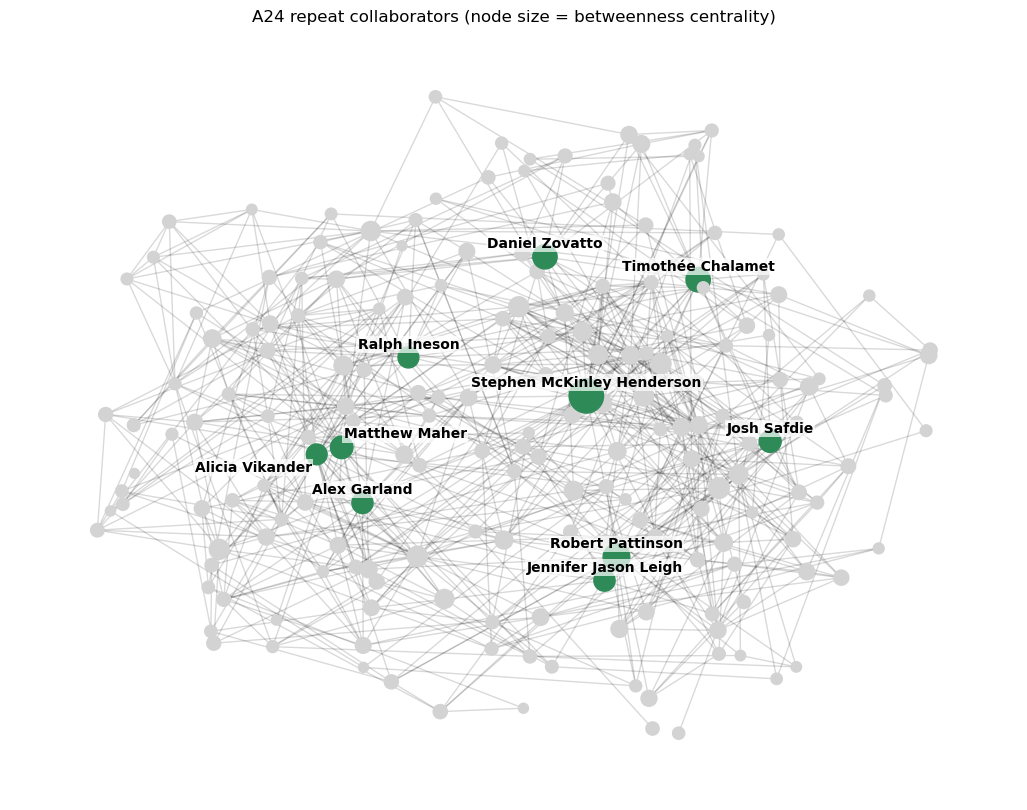

In [32]:
#Node centrality graph
#USED CLAUDE ASSISTANCE
import matplotlib.pyplot as plt

film_counts = df.groupby("person_id")["film_id"].nunique()
repeat = [n for n in g.nodes if film_counts[n] >= 2]
h = g.subgraph(repeat)
print("People in 2+ films:", len(h.nodes))

top_ids = sorted(c_between, key=c_between.get, reverse=True)[:10]

pos = nx.spring_layout(h, seed=42, k=0.6)
plt.figure(figsize=(13, 10))

#Edges
nx.draw_networkx_edges(h, pos, alpha=0.15)

#Nodes
nx.draw_networkx_nodes(
    h, pos,
    node_size=[50 + 5000 * c_between[n] for n in h.nodes],
    node_color=["seagreen" if n in top_ids else "lightgray" for n in h.nodes],
)

#Label positions
label_pos = {n: (x, y + 0.04) for n, (x, y) in pos.items()}

#nudge the two labels that collide
for n in top_ids:
    x, y = pos[n]
    if g.nodes[n]["name"] == "Matthew Maher":
        label_pos[n] = (x + 0.15, y + 0.04)   # push right
    if g.nodes[n]["name"] == "Alicia Vikander":
        label_pos[n] = (x - 0.15, y - 0.04)   # push left and below

#Labels (drawn last, using the adjusted positions)
nx.draw_networkx_labels(
    h, label_pos,
    labels={n: g.nodes[n]["name"] for n in top_ids if n in h},
    font_size=10, font_weight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
)

plt.title("A24 repeat collaborators (node size = betweenness centrality)")
plt.axis("off")
plt.savefig("a24_network.png", dpi=200, bbox_inches="tight")
plt.show()

In [40]:
#Data check: remove Beau Is Afraid (the largest cast), 
#rebuild the graph, and recompute betweenness

df2 = df[df["film"] != "Beau Is Afraid"]
g2 = nx.Graph()
for _, rows in df2.groupby("film_id"):
    ids = rows["person_id"].tolist()
    for i, a in enumerate(ids):
        for b in ids[i+1:]:
            g2.add_edge(a, b)

b2 = nx.betweenness_centrality(g2)
names = dict(zip(df["person_id"], df["person"]))
for n in sorted(b2, key=b2.get, reverse=True)[:10]:
    print(names[n], round(b2[n], 4))

Robert Pattinson 0.0784
Stephen McKinley Henderson 0.0686
Timothée Chalamet 0.0647
Alex Garland 0.0613
Matthew Maher 0.0488
Daniel Zovatto 0.0487
Jennifer Jason Leigh 0.0473
Alicia Vikander 0.0446
Will Poulter 0.0443
Cailee Spaeny 0.042


In [36]:
#Confirm only one studio matched the name "A24" and see what type each title is
check_query = """
SELECT ?film ?filmLabel ?typeLabel ?studio WHERE {
  ?studio rdfs:label "A24"@en .
  ?film wdt:P272|wdt:P750 ?studio .
  ?film wdt:P31 ?type .
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
"""
r = requests.get(
    "https://query.wikidata.org/sparql",
    params={"query": check_query, "format": "json"},
    headers={"User-Agent": "INST414 student project"},
)
check = pd.DataFrame([
    {"title": b["filmLabel"]["value"],
     "type": b["typeLabel"]["value"],
     "studio": b["studio"]["value"]}
    for b in r.json()["results"]["bindings"]
]).drop_duplicates()

print("Studios matched:", check["studio"].nunique())
print(check["type"].value_counts())

Studios matched: 1
type
film                          149
film project                   14
television series              10
miniseries                      2
live action                     1
animated television series      1
retelling                       1
featurette                      1
album                           1
Name: count, dtype: int64


In [38]:
#Count the unique titles in the data
df["film_id"].nunique()

166

In [42]:
#Validation: confirm a collaboration I know is real (The Lighthouse) appears as an edge in the graph
g.has_edge(
    df[df["person"] == "Robert Pattinson"]["person_id"].iloc[0],
    df[df["person"] == "Willem Dafoe"]["person_id"].iloc[0],
)

True

In [44]:
#Validation: confirm Josh Safdie's titles and his direct links to Chalamet and Pattinson
def pid(name):
    return df[df["person"] == name]["person_id"].iloc[0]

print(df[df["person"] == "Josh Safdie"]["film"].tolist())
print(g.has_edge(pid("Josh Safdie"), pid("Timothée Chalamet")))
print(g.has_edge(pid("Josh Safdie"), pid("Robert Pattinson")))

['Marty Supreme', 'Uncut Gems', 'Good Time']
True
True


In [48]:
#Table 2 for the post: top ten with and without Beau Is Afraid, side by side
before = named.sort_values("betweenness", ascending=False)["person"].head(10).tolist()
after = [names[n] for n in sorted(b2, key=b2.get, reverse=True)[:10]]
pd.DataFrame({"With Beau Is Afraid": before, "Without it": after}, index=range(1, 11))

,With Beau Is Afraid,Without it
1,Stephen McKinley Henderson,Robert Pattinson
2,Robert Pattinson,Stephen McKinley Henderson
3,Timothée Chalamet,Timothée Chalamet
4,Daniel Zovatto,Alex Garland
5,Matthew Maher,Matthew Maher
6,Josh Safdie,Daniel Zovatto
7,Jennifer Jason Leigh,Jennifer Jason Leigh
8,Alex Garland,Alicia Vikander
9,Ralph Ineson,Will Poulter
10,Alicia Vikander,Cailee Spaeny
